# TheatreIQ — First-Pass Recommender
### Minneapolis Independent Theaters: Trylon, Riverview & Lagoon

**Goal:** Given real historical showing schedules (`Film Times.csv`) and synthetic performance data,
train a two-stage recommender (ALS → XGBoost) and generate weekly scheduling recommendations
for each theater — plus identify which film types *could have* performed better.

```
Film Times.csv ──► TMDB Enrich ──► Synthetic Performance ──┐
MovieLens 100K ──► ALS ──► Segment Vectors ────────────────┤
                                                            ▼
                                              XGBoost Match Score Grid
                                                            ▼
                                     Greedy Schedule + Missed Opportunity Analysis
```

**Key design choice:** MovieLens supplies demographic taste signals (Stage 1 ALS).
Real theater data + synthetic performance drive Stage 2 evaluation.
No individual user tracking — all modeling is at the *segment* level.

In [1]:
import sys, os, math, warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project path ───────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Load .env (install with: pip install python-dotenv)
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / '.env')
except ImportError:
    print('python-dotenv not installed -- run: pip install python-dotenv')

from theateriq.data import load_ratings, load_users, load_items, GENRE_COLS
from theateriq.segments import add_segments, ARCHETYPES
from theateriq.features import add_slot_calendar, SLOT_NAMES
from theateriq.stage1_als import train_als, export_segment_vectors
from theateriq.stage2_xgb import (
    build_supervised_frame, train_ranker, predict_proba, default_slot_profiles,
)
from theateriq.tmdb_join import TMDB_STAGE2_FEATURES
from theateriq.scheduler import greedy_schedule, apply_archetype_boost
from theateriq.synthetic_performance import generate_performance, VENUE_CAPACITY

sns.set_theme(style='whitegrid')

# ── Config ─────────────────────────────────────────────────────────────────
TMDB_API_KEY   = os.environ.get('TMDB_API_KEY', '')   # loaded from .env
FILM_TIMES_CSV = PROJECT_ROOT / 'Film Times.csv'
CACHE_DIR      = PROJECT_ROOT / '.cache'
CACHE_DIR.mkdir(exist_ok=True)

ALS_FACTORS = 32
ALS_REG     = 0.1
ALS_ITERS   = 20
RANDOM_SEED = 42

SEGMENTS = [
    'under18_F', 'under18_M',
    'age18_34_F', 'age18_34_M',
    'age35_54_F', 'age35_54_M',
    '55plus_F', '55plus_M',
]
VENUE_ARCHETYPE   = 'urban_boutique'
SCREENS_PER_VENUE = {
    'Trylon Cinema':     2,
    'Riverview Theater': 3,
    'Lagoon':            4,
    'Heights Theater':   2,
    'Drafthouse':        8,
}
SLOT_ORDER = [f'slot_{s}' for s in SLOT_NAMES]

print(f'Project root : {PROJECT_ROOT}')
print(f'TMDB API key : {"set ✓" if TMDB_API_KEY else "NOT SET — genre/TMDB features zero-filled"}')
print(f'ml-100k found: {(PROJECT_ROOT / "ml-100k" / "u.data").exists()}')

Project root : /Users/t/Library/Mobile Documents/com~apple~CloudDocs/00 MSBA + Coding/00_spring 2026/04_Big Data Analytics/99_trends marketplace
TMDB API key : set ✓
ml-100k found: True


## 1. Load & Explore Film Times

In [2]:
raw = pd.read_csv(FILM_TIMES_CSV)
print('Columns:', raw.columns.tolist())
print(f'Rows: {len(raw):,}')
raw.head(3)

Columns: ['Date', 'Day', 'Showtime', 'Film Title', 'Film Year', 'Venue']
Rows: 1,523


,Date,Day,Showtime,Film Title,Film Year,Venue
0,2021-02-24,Wed,7:00 PM,Soleil Ô (1967),1967,Trylon Cinema
1,2021-05-28,Fri,7:00 PM,Playtime (1967),1967,Trylon Cinema
2,2021-05-29,Sat,7:00 PM,Playtime (1967),1967,Trylon Cinema


In [3]:
# Drop double-feature rows (title contains '/') -- keep rows with missing Film Year
ft = raw[~raw["Film Title"].astype(str).str.contains("/", na=False)].copy()
ft['Film Year'] = pd.to_numeric(ft['Film Year'], errors='coerce')
# Do NOT dropna -- Riverview/Heights rows have no year but are still valid
ft['Date'] = pd.to_datetime(ft['Date'], errors='coerce')

print(f'Cleaned rows : {len(ft):,}')
print(f'Venues       : {ft["Venue"].value_counts().to_dict()}')
print(f'Missing year : {ft["Film Year"].isna().sum()} rows')

Cleaned rows : 1,518
Venues       : {'Lagoon': 664, 'Trylon Cinema': 422, 'Riverview Theater': 414, 'Heights Theater': 18}
Missing year : 686 rows


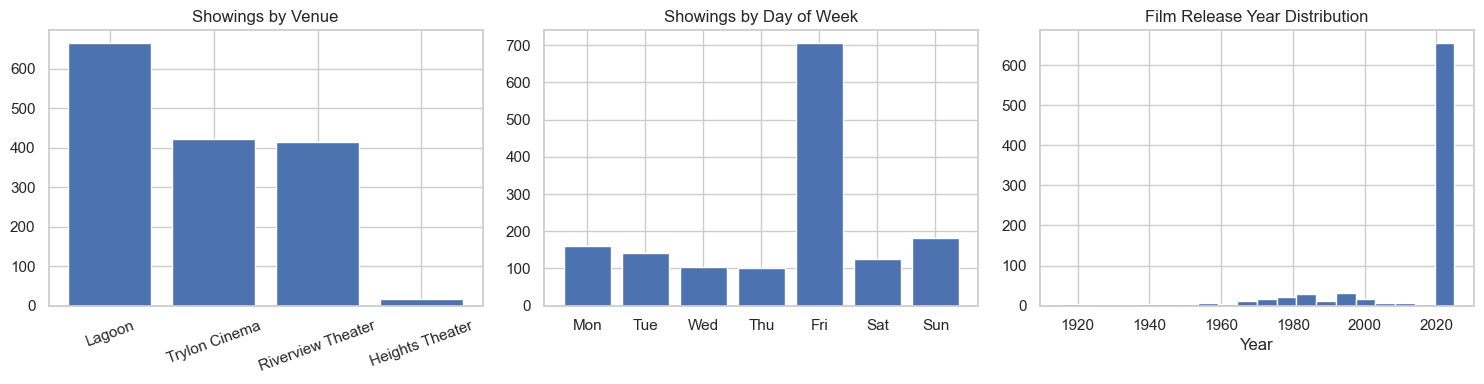

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Showings by venue
vc = ft['Venue'].value_counts()
axes[0].bar(vc.index, vc.values)
axes[0].set_title('Showings by Venue')
axes[0].tick_params(axis='x', rotation=20)

# By day of week
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dc = ft['Day'].value_counts().reindex(day_order, fill_value=0)
axes[1].bar(dc.index, dc.values)
axes[1].set_title('Showings by Day of Week')

# Film release year
axes[2].hist(ft['Film Year'], bins=20, edgecolor='white')
axes[2].set_title('Film Release Year Distribution')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

## 2. TMDB Enrichment

Build a unique film catalog and fetch metadata from TMDB (popularity, rating, runtime,
budget, revenue, genres). Without an API key the pipeline still runs — genre columns
default to `Drama=1` as an arthouse prior, and TMDB numeric features are zero.

In [5]:
import re, time, requests

# TMDB genre name -> MovieLens genre column
TMDB_TO_ML = {
    'Action':'Action', 'Adventure':'Adventure', 'Animation':'Animation',
    'Comedy':'Comedy', 'Crime':'Crime', 'Documentary':'Documentary',
    'Drama':'Drama', 'Family':"Children's", 'Fantasy':'Fantasy',
    'History':'Documentary', 'Horror':'Horror', 'Music':'Musical',
    'Mystery':'Mystery', 'Romance':'Romance', 'Science Fiction':'Sci-Fi',
    'Thriller':'Thriller', 'War':'War', 'Western':'Western',
}

def enrich_film_catalog(catalog_df, api_key='', sleep_s=0.30):
    """Add TMDB numeric features + MovieLens genre flags to catalog."""
    out = catalog_df.copy()
    for col in TMDB_STAGE2_FEATURES:
        out[col] = 0.0
    for col in GENRE_COLS:
        if col not in out.columns:
            out[col] = 0

    if not api_key:
        out['Drama'] = 1   # arthouse prior
        return out

    session = requests.Session()
    for idx, row in out.iterrows():
        raw_title = str(row['film_title'])
        # Strip annotations first, then year, so 'Tenet (2020) — REVIVAL' -> 'Tenet'
        title = re.sub(r'\s*\u2014.*$', '', raw_title).strip()           # em-dash annotations
        title = re.sub(r'\s*\[.*?\]\s*$', '', title).strip()            # [bracket] annotations
        title = re.sub(r'\s*(holdover|second run|\d+st run|\d+nd run)\s*$', '', title, flags=re.IGNORECASE).strip()
        title = re.sub(r'\s*\(\d{4}\)\s*$', '', title).strip()         # trailing (YYYY)
        year  = int(row['film_year']) if pd.notna(row.get('film_year')) else None
        # Try with year first, fall back to year-agnostic if no results
        results = []
        for attempt_year in ([year, None] if year else [None]):
            params = {'api_key': api_key, 'query': title}
            if attempt_year:
                params['year'] = attempt_year
            try:
                r = session.get('https://api.themoviedb.org/3/search/movie', params=params, timeout=30)
                r.raise_for_status()
                results = r.json().get('results') or []
                if results:
                    break
            except Exception as exc:
                print(f'  TMDB search error: {title} -- {exc}')
                break
            time.sleep(sleep_s)
        if not results:
            continue
        try:
            tmdb_id = results[0]['id']
            d_r = session.get(f'https://api.themoviedb.org/3/movie/{tmdb_id}',
                              params={'api_key': api_key}, timeout=30)
            d_r.raise_for_status()
            d = d_r.json()
            out.at[idx, 'tmdb_popularity']    = float(d.get('popularity') or 0)
            out.at[idx, 'tmdb_vote_average']  = float(d.get('vote_average') or 0)
            out.at[idx, 'tmdb_vote_count']    = float(d.get('vote_count') or 0)
            out.at[idx, 'tmdb_runtime']       = float(d.get('runtime') or 0)
            out.at[idx, 'tmdb_budget_log1p']  = math.log1p(float(d.get('budget') or 0))
            out.at[idx, 'tmdb_revenue_log1p'] = math.log1p(float(d.get('revenue') or 0))
            genres = [g['name'] for g in (d.get('genres') or [])]
            for gname in genres:
                ml_col = TMDB_TO_ML.get(gname)
                if ml_col and ml_col in out.columns:
                    out.at[idx, ml_col] = 1
        except Exception as exc:
            print(f'  TMDB detail miss: {title} ({year}) -- {exc}')
        time.sleep(sleep_s)
    return out

# Build unique film catalog
catalog = (
    ft[['Film Title', 'Film Year']]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={'Film Title': 'film_title', 'Film Year': 'film_year'})
)
catalog['item_id'] = 10_001 + catalog.index   # IDs > 1682 to avoid MovieLens collision
print(f'Unique films: {len(catalog)}')

def gap_fill_tmdb(df, api_key='', sleep_s=0.30):
    """
    Two-pass fix for zero-popularity entries:
      1. Propagate TMDB data from clean-title duplicates (e.g. 'Barbie' -> 'Barbie (2023)')
      2. Fresh API calls with stripped title for entries with no clean-title match
    Runs on every Cell 8 execution so the cache improves incrementally.
    """
    import math as _math
    out = df.copy()
    tmdb_cols = TMDB_STAGE2_FEATURES
    genre_cols = [c for c in GENRE_COLS if c in out.columns]

    # ── Pass 1: propagate from clean-title duplicates ──────────────────────
    for idx, row in out[out['tmdb_popularity'] == 0].iterrows():
        raw   = str(row['film_title'])
        clean = re.sub(r'\s*\u2014.*$', '', raw).strip()
        clean = re.sub(r'\s*\(\d{4}\)\s*$', '', clean).strip()
        if clean == raw:
            continue
        yr   = row.get('film_year')
        mask = (out['film_title'] == clean) & (out['tmdb_popularity'] > 0)
        if pd.notna(yr):
            mask = mask & ((out['film_year'] == yr) | out['film_year'].isna())
        candidates = out[mask]
        if not candidates.empty:
            for col in tmdb_cols + genre_cols:
                if col in out.columns:
                    out.at[idx, col] = candidates.iloc[0][col]

    # ── Pass 2: fresh API calls for remaining zeros ────────────────────────
    if not api_key:
        return out

    session = requests.Session()
    still_zero = out[out['tmdb_popularity'] == 0].copy()
    fixed = 0
    for idx, row in still_zero.iterrows():
        raw   = str(row['film_title'])
        clean = re.sub(r'\s*\u2014.*$', '', raw).strip()           # em-dash annotations
        clean = re.sub(r'\s*\[.*?\]\s*$', '', clean).strip()      # [bracket] annotations
        clean = re.sub(r'\s*(holdover|second run|\d+st run|\d+nd run)\s*$', '', clean, flags=re.IGNORECASE).strip()
        clean = re.sub(r'\s*\(\d{4}\)\s*$', '', clean).strip()   # trailing (YYYY)
        yr    = int(row['film_year']) if pd.notna(row.get('film_year')) else None

        results = []
        for attempt_year in ([yr, None] if yr else [None]):
            params = {'api_key': api_key, 'query': clean}
            if attempt_year:
                params['year'] = attempt_year
            try:
                r = session.get('https://api.themoviedb.org/3/search/movie', params=params, timeout=30)
                r.raise_for_status()
                results = r.json().get('results') or []
                if results:
                    break
            except Exception as exc:
                print(f'  gap-fill search error: {clean!r} -- {exc}')
                break
            time.sleep(sleep_s)
        if not results:
            continue
        try:
            tmdb_id = results[0]['id']
            d_r = session.get(f'https://api.themoviedb.org/3/movie/{tmdb_id}',
                              params={'api_key': api_key}, timeout=30)
            d_r.raise_for_status()
            d = d_r.json()
            out.at[idx, 'tmdb_popularity']    = float(d.get('popularity') or 0)
            out.at[idx, 'tmdb_vote_average']  = float(d.get('vote_average') or 0)
            out.at[idx, 'tmdb_vote_count']    = float(d.get('vote_count') or 0)
            out.at[idx, 'tmdb_runtime']       = float(d.get('runtime') or 0)
            out.at[idx, 'tmdb_budget_log1p']  = _math.log1p(float(d.get('budget') or 0))
            out.at[idx, 'tmdb_revenue_log1p'] = _math.log1p(float(d.get('revenue') or 0))
            for gname in [g['name'] for g in (d.get('genres') or [])]:
                ml_col = TMDB_TO_ML.get(gname)
                if ml_col and ml_col in out.columns:
                    out.at[idx, ml_col] = 1
            fixed += 1
        except Exception as exc:
            print(f'  gap-fill detail error: {clean!r} -- {exc}')
        time.sleep(sleep_s)

    if fixed:
        print(f'  gap-fill: recovered {fixed} additional films via fresh API calls')
    return out

Unique films: 509


In [6]:
cache_path = CACHE_DIR / 'film_catalog_enriched.csv'
if cache_path.exists():
    catalog_enriched = pd.read_csv(cache_path)
    print(f'Loaded from cache: {len(catalog_enriched)} films')
else:
    print('Fetching TMDB data (may take a few minutes if API key is set)...')
    catalog_enriched = enrich_film_catalog(catalog, api_key=TMDB_API_KEY)
    catalog_enriched.to_csv(cache_path, index=False)
    print(f'Saved {len(catalog_enriched)} films to cache')

# Gap-fill: runs on every execution to recover zeros (safe to re-run)
zeros_before = (catalog_enriched['tmdb_popularity'] == 0).sum()
catalog_enriched = gap_fill_tmdb(catalog_enriched, api_key=TMDB_API_KEY)
zeros_after = (catalog_enriched['tmdb_popularity'] == 0).sum()
if zeros_after < zeros_before:
    catalog_enriched.to_csv(cache_path, index=False)
    print(f'Gap-fill improved: {zeros_before} → {zeros_after} zeros remaining')

tmdb_hits = (catalog_enriched['tmdb_popularity'] > 0).sum()
print(f'TMDB enriched: {tmdb_hits}/{len(catalog_enriched)} films ({100*tmdb_hits/max(len(catalog_enriched),1):.0f}%)')
catalog_enriched.head(3)

Loaded from cache: 253 films
TMDB enriched: 183/253 films (72%)


,film_title,film_year,item_id,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,tmdb_runtime,tmdb_budget_log1p,tmdb_revenue_log1p,unknown,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,Soleil Ô (1967),1967,10001,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1,Playtime (1967),1967,10002,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,Safe (1995),1995,10003,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Synthetic Performance

No box-office records exist for these theaters, so we generate plausible performance
using a structured noise model:

```
occupancy = base_occ(0.45) × dow_mult × slot_mult × tmdb_pop_mult × N(1, 0.15)
revenue   = seats_filled × ticket_price  ($13 evening / $10 matinee)
```

Venue capacities: Trylon 175 · Riverview 250 · Lagoon 350

In [7]:
# Merge TMDB popularity into Film Times for the occupancy signal
ft_merged = ft.merge(
    catalog_enriched[['film_title', 'film_year', 'tmdb_popularity']]
        .rename(columns={'film_title': 'Film Title', 'film_year': 'Film Year'}),
    on=['Film Title', 'Film Year'],
    how='left',
)

ft_perf = generate_performance(ft_merged, random_state=RANDOM_SEED)

print(f'Rows with performance: {len(ft_perf):,}')
print(ft_perf['occupancy_rate'].describe().round(3))

# Aggregate per film per venue
film_agg = (
    ft_perf
    .groupby(['Film Title', 'Film Year', 'Venue'])
    .agg(
        showings   =('occupancy_rate', 'count'),
        avg_occ    =('occupancy_rate', 'mean'),
        total_rev  =('revenue', 'sum'),
    )
    .reset_index()
    .sort_values('avg_occ', ascending=False)
)
print(f'\nTop-5 by occupancy:')
film_agg.head(5).to_string(index=False)

Rows with performance: 1,518
count    1518.000
mean        0.365
std         0.107
min         0.132
25%         0.271
50%         0.368
75%         0.442
max         0.685
Name: occupancy_rate, dtype: float64

Top-5 by occupancy:


'                         Film Title  Film Year  Venue  showings  avg_occ  total_rev\n        The Super Mario Bros. Movie     2023.0 Lagoon         4 0.652119    10553.0\n                               Drop     2025.0 Lagoon         1 0.560686     2548.0\nLicorice Pizza (2021) — PTA REVIVAL     2021.0 Lagoon         1 0.525940     2392.0\n                          Uncharted     2022.0 Lagoon         4 0.515949     8417.0\n                      Lilo & Stitch     2025.0 Lagoon         4 0.515949     8394.0'

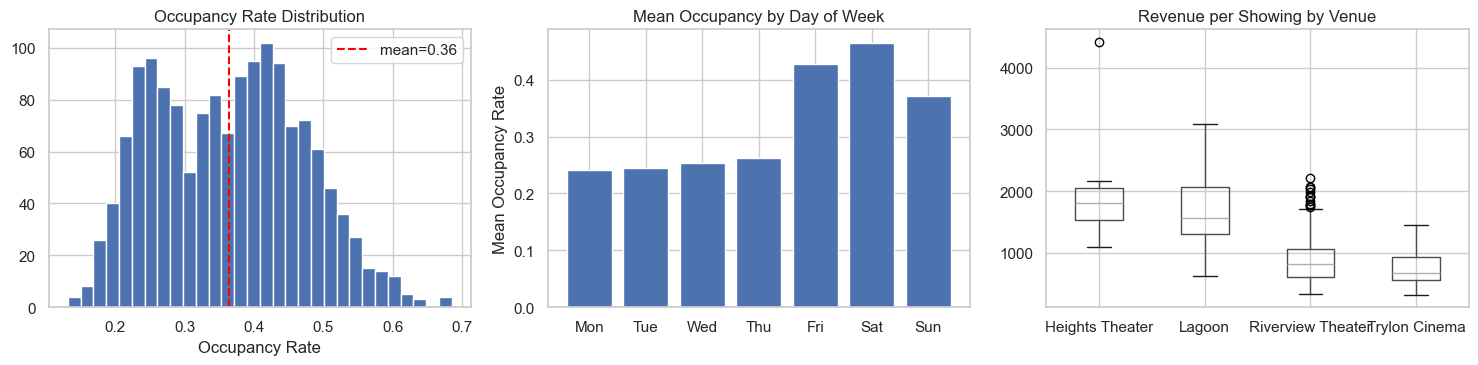

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ft_perf['occupancy_rate'], bins=30, edgecolor='white')
axes[0].axvline(ft_perf['occupancy_rate'].mean(), color='red', ls='--',
                label=f'mean={ft_perf["occupancy_rate"].mean():.2f}')
axes[0].set_title('Occupancy Rate Distribution')
axes[0].set_xlabel('Occupancy Rate')
axes[0].legend()

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_means = ft_perf.groupby('Day')['occupancy_rate'].mean().reindex(day_order)
axes[1].bar(day_means.index, day_means.values)
axes[1].set_title('Mean Occupancy by Day of Week')
axes[1].set_ylabel('Mean Occupancy Rate')

ft_perf.boxplot(column='revenue', by='Venue', ax=axes[2])
axes[2].set_title('Revenue per Showing by Venue')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. MovieLens 100K + ALS Training

Stage 1 learns *which film attributes resonate with which demographic segments*
from 100K real ratings. The output — segment latent vectors — is the demographic
taste signal we layer onto real theater films in Stage 2.

> **Runtime:** ALS training takes ~30–90 seconds.

In [9]:
print('Loading MovieLens 100K...')
ratings = load_ratings()
users   = load_users()
items   = load_items()

users_seg = add_segments(users)

# Time-based 80/20 split
cutoff = ratings['datetime'].quantile(0.80)
train_r = ratings[ratings['datetime'] <= cutoff].copy()
test_r  = ratings[ratings['datetime'] >  cutoff].copy()

print(f'Ratings : {len(ratings):,}  |  Train: {len(train_r):,}  |  Test: {len(test_r):,}')
print(f'Users   : {len(users):,}  |  Items: {len(items):,}')
print('Segments:', users_seg['segment'].value_counts().to_dict())

Loading MovieLens 100K...
Ratings : 100,000  |  Train: 80,003  |  Test: 19,997
Users   : 943  |  Items: 1,682
Segments: {'age18_34_M': 374, 'age35_54_M': 219, 'age18_34_F': 134, 'age35_54_F': 117, '55plus_M': 54, 'under18_M': 23, 'under18_F': 13, '55plus_F': 9}


In [10]:
import io, contextlib

print(f'Training ALS  (k={ALS_FACTORS}, reg={ALS_REG}, iters={ALS_ITERS})...')
als_model = train_als(
    train_r,
    n_factors=ALS_FACTORS,
    reg=ALS_REG,
    n_iters=ALS_ITERS,
    random_state=RANDOM_SEED,
)
segment_vectors = export_segment_vectors(als_model, users_seg)
print('Done.')
print(segment_vectors[['segment', 'segment_user_count']].to_string(index=False))

Training ALS  (k=32, reg=0.1, iters=20)...
Done.
   segment  segment_user_count
age18_34_M                 316
age35_54_F                  83
age18_34_F                 115
age35_54_M                 165
 under18_M                  20
  55plus_M                  35
  55plus_F                   6
 under18_F                  11


## 5. Genre Bridge (Cold-Start Resolution)

Real films (Playtime, Fitzcarraldo, etc.) are not in MovieLens, so they have no
ALS item vectors. We bridge the gap in priority order:

1. **Exact title match** in MovieLens → use its actual latent factors  
2. **Genre cosine similarity** → weighted average of top-3 nearest MovieLens items  
3. **Drama fallback** → mean of all MovieLens Drama items (arthouse prior)

In [11]:
def _norm_title(t):
    """Lowercase, strip year suffix, remove non-alphanumeric."""
    t = str(t).strip()
    # Remove trailing (YYYY)
    if t.endswith(')') and '(' in t:
        p = t.rfind('(')
        inner = t[p+1:t.rfind(')')]
        if inner.isdigit():
            t = t[:p].strip()
    return ''.join(c for c in t.lower() if c.isalnum() or c == ' ').strip()


def bridge_film_factors(catalog_df, ml_items, als_model, k=32, top_n=3):
    """Return DataFrame with item_id + item_als_0..k-1 columns for each real film."""
    ml = ml_items.copy()
    ml['_tnorm'] = ml['title'].apply(_norm_title)
    ml_genre_mat = ml[GENRE_COLS].fillna(0).values.astype(float)   # (n_ml, 19)

    # Precompute Drama fallback
    drama_idxs = [
        als_model.item_id_to_idx[int(r['item_id'])]
        for _, r in ml[ml['Drama'] == 1].iterrows()
        if int(r['item_id']) in als_model.item_id_to_idx
    ]
    drama_fallback = als_model.item_factors[drama_idxs].mean(axis=0) if drama_idxs else np.zeros(k)

    rows = []
    for _, row in catalog_df.iterrows():
        tnorm = _norm_title(str(row['film_title']))

        # 1. Exact match
        match = ml[ml['_tnorm'] == tnorm]
        if not match.empty:
            mid = int(match.iloc[0]['item_id'])
            if mid in als_model.item_id_to_idx:
                vec = als_model.item_factors[als_model.item_id_to_idx[mid]]
                rows.append({'item_id': int(row['item_id']), 'bridge': 'exact',
                             **{f'item_als_{j}': float(vec[j]) for j in range(k)}})
                continue

        # 2. Genre cosine bridge
        film_genre = np.array([float(row.get(g, 0)) for g in GENRE_COLS])
        if film_genre.sum() > 0:
            fnorm = film_genre / (np.linalg.norm(film_genre) + 1e-9)
            ml_norms = ml_genre_mat / (np.linalg.norm(ml_genre_mat, axis=1, keepdims=True) + 1e-9)
            sims = ml_norms @ fnorm
            top_idx = np.argsort(sims)[-top_n:][::-1]
            weights = np.maximum(sims[top_idx], 0.0)
            weights = weights / (weights.sum() + 1e-9)
            vecs, ws = [], []
            for i, w in zip(top_idx, weights):
                mid = int(ml.iloc[i]['item_id'])
                if mid in als_model.item_id_to_idx:
                    vecs.append(als_model.item_factors[als_model.item_id_to_idx[mid]])
                    ws.append(w)
            if vecs:
                ws_arr = np.array(ws); ws_arr /= ws_arr.sum()
                vec = sum(v * w for v, w in zip(vecs, ws_arr))
            else:
                vec = drama_fallback
            rows.append({'item_id': int(row['item_id']), 'bridge': 'genre',
                         **{f'item_als_{j}': float(vec[j]) for j in range(k)}})
        else:
            # 3. Drama fallback
            rows.append({'item_id': int(row['item_id']), 'bridge': 'drama_fallback',
                         **{f'item_als_{j}': float(drama_fallback[j]) for j in range(k)}})

    return pd.DataFrame(rows)


bridge_df = bridge_film_factors(catalog_enriched, items, als_model)
print('Bridge method breakdown:')
print(bridge_df['bridge'].value_counts().to_string())

Bridge method breakdown:
bridge
genre             180
drama_fallback     63
exact              10


In [12]:
# Assemble items_for_scoring: catalog metadata + bridged ALS factors
items_for_scoring = catalog_enriched.merge(
    bridge_df.drop(columns=['bridge']), on='item_id', how='left'
)

for col in TMDB_STAGE2_FEATURES:
    if col not in items_for_scoring.columns:
        items_for_scoring[col] = 0.0
    items_for_scoring[col] = items_for_scoring[col].fillna(0.0)

for col in GENRE_COLS:
    if col not in items_for_scoring.columns:
        items_for_scoring[col] = 0
    items_for_scoring[col] = items_for_scoring[col].fillna(0)

for j in range(ALS_FACTORS):
    c = f'item_als_{j}'
    items_for_scoring[c] = items_for_scoring[c].fillna(0.0)

print(f'items_for_scoring: {items_for_scoring.shape}')

items_for_scoring: (253, 60)


## 6. XGBoost Training & Evaluation

Stage 2 trains on MovieLens ratings (label: `rating >= 4`) with 74 features:
segment ALS vectors, item ALS vectors, genre flags, TMDB metrics, slot/calendar.
This gives us a ranker we can apply to *any* film — including real theater films.

In [13]:
train_sc = add_slot_calendar(train_r, dt_col='datetime')

print('Building supervised frame...')
train_frame, feature_names = build_supervised_frame(
    train_sc, users_seg, items, als_model, segment_vectors
)
print(f'Frame: {train_frame.shape}  |  features: {len(feature_names)}  |  positive rate: {train_frame["label_positive"].mean():.3f}')

print('\nTraining XGBoost ranker...')
with contextlib.redirect_stdout(io.StringIO()):
    ranker = train_ranker(train_frame, feature_names, seed=RANDOM_SEED)
print('Done.')

Building supervised frame...
Frame: (80003, 105)  |  features: 97  |  positive rate: 0.551

Training XGBoost ranker...
Done.


In [14]:
from sklearn.metrics import roc_auc_score

test_sc = add_slot_calendar(test_r, dt_col='datetime')
test_frame, _ = build_supervised_frame(test_sc, users_seg, items, als_model, segment_vectors)
test_proba = predict_proba(ranker, test_frame)
auc = roc_auc_score(test_frame['label_positive'], test_proba)
print(f'MovieLens holdout ROC-AUC: {auc:.4f}')

# Top features
import xgboost as xgb
fi = pd.Series(ranker.booster.get_score(importance_type='gain'), name='gain').sort_values(ascending=False)
print('\nTop-10 features by gain:')
print(fi.head(10).round(1).to_string())

MovieLens holdout ROC-AUC: 0.6961

Top-10 features by gain:
item_als_2     83.7
item_als_29    58.5
item_als_15    52.1
Documentary    47.5
item_als_7     37.8
Drama          32.2
item_als_30    31.2
item_als_27    26.6
item_als_25    23.8
item_als_18    23.6


## 7. Match Score Grid

Score every real film across all demographic segments and time slots.
Output: a `match_score_0_100` for each (film, segment, slot) triple.

In [15]:
def score_real_films(ranker, segment_vectors, items_df, slate_ids, segments, slot_profiles):
    """
    Compute match scores for real films using pre-bridged ALS vectors.
    Bypasses the ALS model lookup (cold-start safe).
    """
    fn = ranker.feature_names
    k  = ALS_FACTORS
    seg_cols      = [f'seg_als_{j}' for j in range(k)]
    item_als_cols = [f'item_als_{j}' for j in range(k)]
    META_COLS     = ['cal_month', 'cal_dow', 'cal_is_weekend']
    slot_cols     = [f'slot_{s}' for s in SLOT_NAMES]

    slate = items_df[items_df['item_id'].isin(slate_ids)].copy()

    feat_rows, meta_rows = [], []
    for seg in segments:
        sv = segment_vectors[segment_vectors['segment'] == seg]
        seg_vec = {c: float(sv.iloc[0][c]) if not sv.empty else 0.0 for c in seg_cols}

        for slot in slot_profiles:
            slot_key = next(
                (f'slot_{s}' for s in SLOT_NAMES if int(slot.get(f'slot_{s}', 0)) == 1),
                'slot_unknown',
            )
            for _, movie in slate.iterrows():
                feat = {}
                for name in fn:
                    if name in seg_vec:
                        feat[name] = seg_vec[name]
                    elif name in item_als_cols:
                        feat[name] = float(movie.get(name, 0.0) or 0.0)
                    elif name in GENRE_COLS or name in TMDB_STAGE2_FEATURES:
                        feat[name] = float(movie.get(name, 0.0) or 0.0)
                    elif name in slot_cols:
                        feat[name] = float(int(slot.get(name, 0)))
                    elif name in META_COLS:
                        feat[name] = float(slot.get(name, 0))
                    else:
                        feat[name] = 0.0
                feat_rows.append(feat)
                meta_rows.append({
                    'segment': seg,
                    'item_id': int(movie['item_id']),
                    'title':   str(movie.get('film_title', movie.get('title', ''))),
                    'slot_key': slot_key,
                })

    feat_df = pd.DataFrame(feat_rows, columns=fn)
    X = feat_df.to_numpy(dtype=np.float32)
    d = xgb.DMatrix(X, feature_names=fn)
    p = ranker.booster.predict(d)

    out = pd.DataFrame(meta_rows)
    out['match_score_0_100'] = np.clip(p * 100.0, 0.0, 100.0)
    return out


slate_ids  = items_for_scoring['item_id'].tolist()
slot_profs = default_slot_profiles()

print(f'Scoring {len(slate_ids)} films x {len(SEGMENTS)} segments x {len(slot_profs)} slots...')
score_grid = score_real_films(
    ranker, segment_vectors, items_for_scoring,
    slate_ids, SEGMENTS, slot_profs,
)
print(f'Grid: {score_grid.shape}  |  score range: {score_grid["match_score_0_100"].min():.1f} – {score_grid["match_score_0_100"].max():.1f}')

Scoring 253 films x 8 segments x 5 slots...
Grid: (10120, 5)  |  score range: 7.2 – 84.4


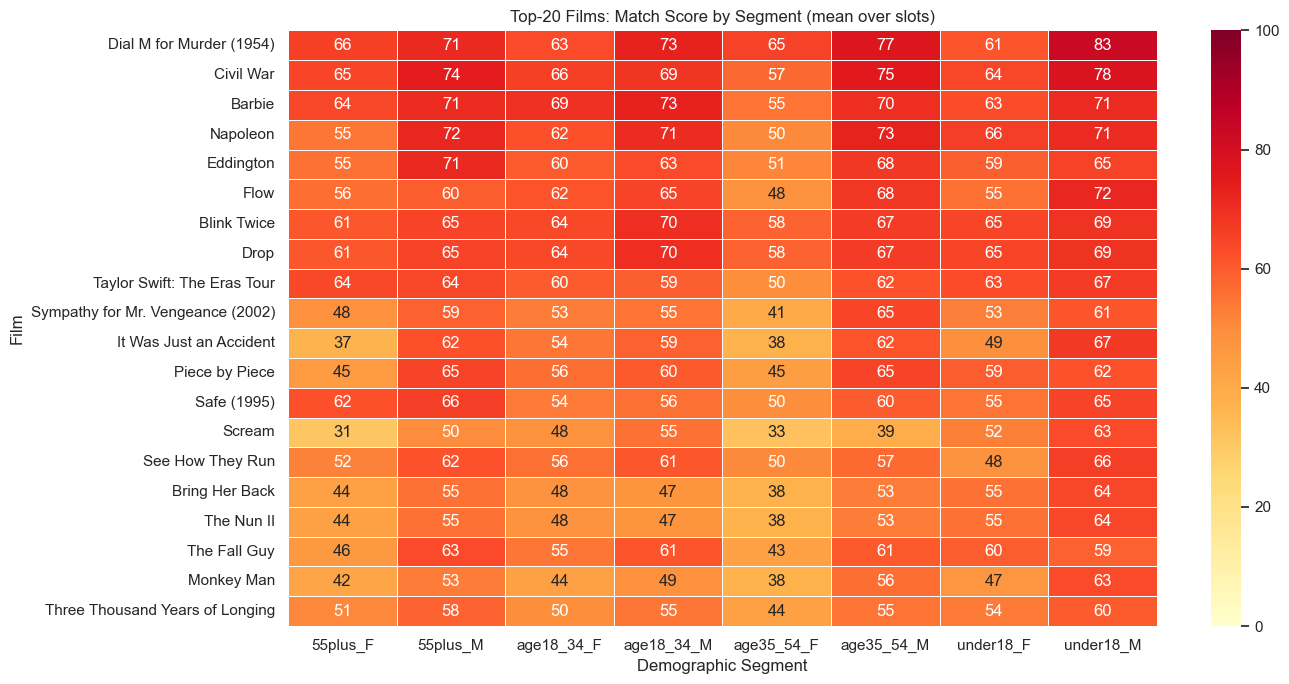

In [16]:
# Heatmap: top-20 films by max score, broken down by segment
film_max = (
    score_grid.groupby(['item_id', 'title'])['match_score_0_100']
    .max().reset_index()
    .sort_values('match_score_0_100', ascending=False)
)
top20_titles = film_max.head(20)['title'].tolist()

pivot = (
    score_grid[score_grid['title'].isin(top20_titles)]
    .groupby(['title', 'segment'])['match_score_0_100']
    .mean()
    .unstack('segment')
    .reindex(top20_titles)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            vmin=0, vmax=100, linewidths=0.4, ax=ax)
ax.set_title('Top-20 Films: Match Score by Segment (mean over slots)')
ax.set_xlabel('Demographic Segment')
ax.set_ylabel('Film')
plt.tight_layout()
plt.show()

## 8. Weekly Schedule Recommendations

For each venue, greedy assignment fills screens × slots with the highest-scoring
available film (archetype boosts applied first).

Confidence labels:
- **high_confidence** (≥75): strong match, no promotion needed
- **promotional_support** (50–74): moderate match, light outreach recommended  
- **consider_dropping** (<50): weak match

In [17]:
venue_schedules = {}
for venue, n_screens in SCREENS_PER_VENUE.items():
    # Films that appeared at this venue
    venue_titles  = ft_perf[ft_perf['Venue'] == venue]['Film Title'].unique()
    venue_ids     = catalog_enriched[catalog_enriched['film_title'].isin(venue_titles)]['item_id'].tolist()
    venue_grid    = score_grid[score_grid['item_id'].isin(venue_ids)].copy()

    if venue_grid.empty:
        print(f'{venue}: no scored films -- skipping')
        continue

    sched = greedy_schedule(
        venue_grid,
        screens=n_screens,
        slot_order=SLOT_ORDER,
        archetype=VENUE_ARCHETYPE,
    )
    venue_schedules[venue] = sched

    print(f'\n{"="*60}')
    print(f'  {venue}  ({n_screens} screens, archetype={VENUE_ARCHETYPE})')
    print(f'{"="*60}')
    display_cols = ['screen_id', 'slot_key', 'title', 'best_segment_score', 'confidence_label']
    print(sched[display_cols].to_string(index=False))


  Trylon Cinema  (2 screens, archetype=urban_boutique)
 screen_id           slot_key                             title  best_segment_score    confidence_label
         1     slot_fri_prime          Dial M for Murder (1954)           85.643895     high_confidence
         1   slot_sat_matinee                       Safe (1995)           70.301351 promotional_support
         1     slot_sat_prime Sympathy for Mr. Vengeance (2002)           74.846196 promotional_support
         1   slot_sun_matinee                   Scream 2 (1997)           58.619404 promotional_support
         1 slot_weekday_other                     Scream (1996)           51.743114 promotional_support
         2     slot_fri_prime               Strange Days (1995)           55.138503 promotional_support
         2   slot_sat_matinee      Bram Stoker's Dracula (1992)           47.039866   consider_dropping
         2     slot_sat_prime                   Soleil Ô (1967)           42.112700   consider_dropping
        

## 9. What Could Have Done Better?

Compare predicted Match Score against simulated occupancy.
Films with high Match Score that underperformed reveal *promotion gaps*.
Films with low Match Score that were heavily scheduled reveal *programming mismatches*.

In [18]:
# Max match score per film (over all segments and slots)
film_max_score = (
    score_grid.groupby(['item_id', 'title'])['match_score_0_100']
    .max().reset_index()
    .rename(columns={'match_score_0_100': 'max_match_score'})
)

# Per-film average occupancy across all venues
film_occ_avg = (
    ft_perf.groupby(['Film Title', 'Film Year'])['occupancy_rate']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_occ', 'count': 'total_showings',
                     'Film Title': 'film_title', 'Film Year': 'film_year'})
)

# Join everything
analysis = (
    catalog_enriched[['item_id', 'film_title', 'film_year']]
    .merge(film_max_score[['item_id', 'max_match_score']], on='item_id', how='left')
    .merge(film_occ_avg, on=['film_title', 'film_year'], how='left')
)
analysis = analysis.dropna(subset=['max_match_score', 'avg_occ'])
analysis['confidence'] = pd.cut(
    analysis['max_match_score'],
    bins=[0, 35, 60, 100],
    labels=['consider_dropping', 'promotional_support', 'high_confidence']
)

print(f'Films in analysis: {len(analysis)}')
print(analysis['confidence'].value_counts().to_string())

Films in analysis: 253
confidence
promotional_support    160
high_confidence         64
consider_dropping       29


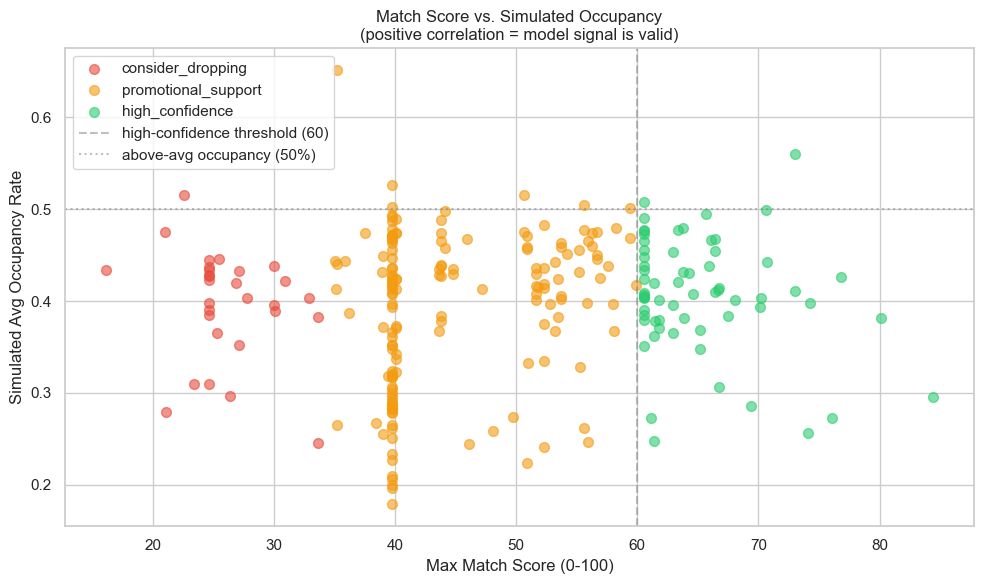

Pearson r (match score vs. occupancy): 0.111
Note: some correlation is expected since both use TMDB popularity; a well-calibrated model.


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'high_confidence': '#2ecc71', 'promotional_support': '#f39c12', 'consider_dropping': '#e74c3c'}
for label, grp in analysis.groupby('confidence', observed=True):
    ax.scatter(grp['max_match_score'], grp['avg_occ'],
               label=str(label), alpha=0.6, s=50, color=colors.get(str(label), 'gray'))

ax.axvline(60, color='gray', ls='--', alpha=0.5, label='high-confidence threshold (60)')
ax.axhline(0.50, color='gray', ls=':',  alpha=0.5, label='above-avg occupancy (50%)')
ax.set_xlabel('Max Match Score (0-100)')
ax.set_ylabel('Simulated Avg Occupancy Rate')
ax.set_title('Match Score vs. Simulated Occupancy\n(positive correlation = model signal is valid)')
ax.legend()
plt.tight_layout()
plt.show()

corr = analysis[['max_match_score', 'avg_occ']].corr().iloc[0, 1]
print(f'Pearson r (match score vs. occupancy): {corr:.3f}')
print('Note: some correlation is expected since both use TMDB popularity; a well-calibrated model.')

In [20]:
print('Films shown with LOW match score -- consider replacing in future programming:')
low = (
    analysis[analysis['max_match_score'] < 35]
    .sort_values('max_match_score')
    [['film_title', 'film_year', 'max_match_score', 'avg_occ', 'total_showings']]
    .head(10)
)
print(low.to_string(index=False))

print('\nFilms with HIGH match score -- strongest programmable content:')
high = (
    analysis[analysis['max_match_score'] >= 60]
    .sort_values('max_match_score', ascending=False)
    [['film_title', 'film_year', 'max_match_score', 'avg_occ', 'total_showings']]
    .head(10)
)
print(high.to_string(index=False))

Films shown with LOW match score -- consider replacing in future programming:
                           film_title  film_year  max_match_score  avg_occ  total_showings
                                Wonka       2023        16.174408 0.433853               4
                              Warfare       2025        21.015858 0.475615               3
                    A Minecraft Movie       2025        21.087513 0.279689               3
                        Lilo & Stitch       2025        22.554964 0.515949               4
                                 Wish       2023        23.425070 0.309118               2
                    Kinds of Kindness       2024        24.648392 0.397491               3
                     American Fiction       2023        24.648392 0.434048               3
                        Asteroid City       2023        24.648392 0.309275               3
Are You There God? It's Me, Margaret.       2023        24.648392 0.389922               3
            

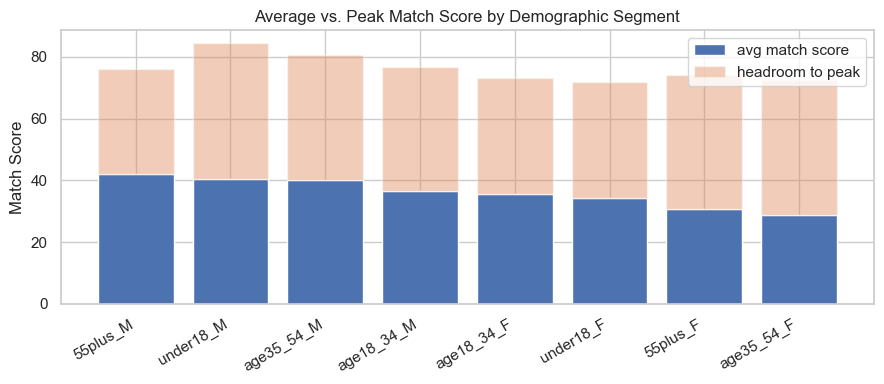


Segments with large headroom = underserved by current programming.


In [21]:
# Per-segment underperformance: which segment had highest predicted demand
# but lowest average match score across all shown films?
seg_means = (
    score_grid.groupby('segment')['match_score_0_100']
    .agg(['mean', 'max'])
    .rename(columns={'mean': 'avg_score', 'max': 'peak_score'})
    .sort_values('avg_score', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(seg_means))
ax.bar(x, seg_means['avg_score'], label='avg match score')
ax.bar(x, seg_means['peak_score'] - seg_means['avg_score'],
       bottom=seg_means['avg_score'], alpha=0.4, label='headroom to peak')
ax.set_xticks(list(x))
ax.set_xticklabels(seg_means['segment'], rotation=30, ha='right')
ax.set_ylabel('Match Score')
ax.set_title('Average vs. Peak Match Score by Demographic Segment')
ax.legend()
plt.tight_layout()
plt.show()
print('\nSegments with large headroom = underserved by current programming.')